# 示例 3：ETF 月定投（沪深300ETF，510300.SH）

每月第一个交易日定额买入固定金额的沪深300ETF（510300.SH），长期摊薄持仓成本。

演示「月频调仓」——框架只提供 run_daily，这里用「月份是否变化」判断是否进入新月份。

**运行说明**

- 数据：仓库内置 `./data`（全市场 2020 上半年，股票 + 基金）
- 内核：请选择带 `xxybacktest` 依赖的 Python 内核（如本机注册的 `xxybacktest (vnpy)` 环境）。
- 操作：在仓库根目录打开本 notebook，「重启内核并运行所有单元格」即可。
- 回测曲线、回撤与绩效指标表会在最后一个代码单元格运行后自动显示（图已预执行嵌入，离线打开也能直接看）。

In [1]:
%matplotlib inline
from xxybacktest import run_backtest

In [2]:
CODE = "510300.SH"
MONTHLY_CASH = 50000  # 每月定投金额（元）


def initialize(context):
    context.run_daily(rebalance, "09:31")
    context.last_month = None


def rebalance(context):
    month = context.current_dt.month
    if context.last_month == month:
        return  # 同一个月只买一次
    context.last_month = month
    context.order_value(CODE, MONTHLY_CASH)


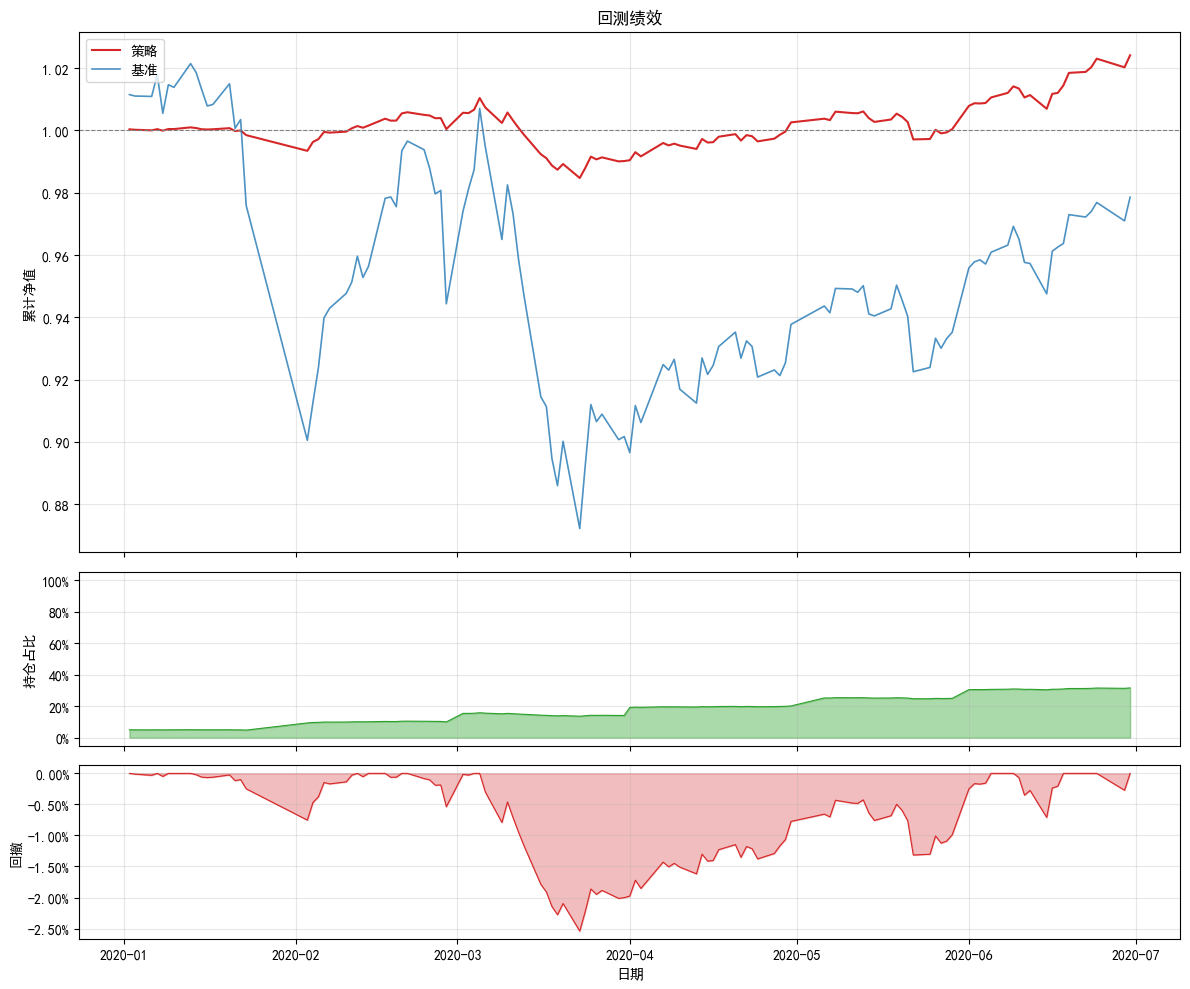

指标,值
总收益率,2.41%
年化收益率,5.27%
CAGR,5.27%
年化波动率,3.53%
最大回撤,-2.54%
夏普比率,1.4731
索提诺比率,2.2180
卡尔玛比率,2.0730
Omega,1.2928
Alpha,0.0567


Loading ITables v2.7.0 from the internet... (need help?)


Loading ITables v2.7.0 from the internet... (need help?)


In [ ]:
ctx = run_backtest(
    initialize, None,
    start_date="2020-01-02", end_date="2020-06-30",
    capital=1000000, data_path="../data",
    benchmark="000001.SH", asset_type="fund", plot=True,
)
